# Обучение основных моделей

In [1]:
import pandas as pd
import pickle
import warnings
import optuna
import os
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import fbeta_score

from sklearn.linear_model import LogisticRegressionCV, RidgeClassifierCV
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.svm import SVC

/Users/nikitadolgov/miniforge3/envs/research_test/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Здесь будут обучены модели на варианте со стеммингом

In [2]:
full_df = pd.read_csv(fr'DataBases/prepared_datasets/full_dataset_emotions_text.csv').dropna()
full_df

,text,emotion,full_prep_text,no_stem_text
0,carefully word blog posts amount criticism hea...,0,care word blog post amount critic hear place c...,carefully word blog posts amount criticism hea...
1,cannot remember little mermaid feeling carefre...,1,rememb littl mermaid feel carefre beauti life ...,remember little mermaid feeling carefree beaut...
2,not feeling super well turns cold knocked next...,1,feel super well turn cold knock next three wee...,feeling super well turns cold knocked next thr...
3,feel honored part group amazing talents,1,feel honor part group amaz talent,feel honored part group amazing talents
4,think helping also began feel pretty lonely lo...,0,think help also began feel pretti lone lot peo...,think helping also began feel pretty lonely lo...
...,...,...,...,...
282817,feel honored motivated share world life changi...,1,feel honor motiv share world life chang gift a...,feel honored motivated share world life changi...
282818,feel like gloaty really delighted,1,feel like gloati realli delight,feel like gloaty really delighted
282819,feel little energetic one day next several day...,1,feel littl energet one day next sever day hard...,feel little energetic one day next several day...
282820,feel work experience fell although fantastic o...,1,feel work experi fell although fantast opportu...,feel work experience fell although fantastic o...


In [3]:
x_train, x_test, y_train, y_test = train_test_split(full_df.full_prep_text, full_df.emotion, test_size=0.15, random_state=42, stratify=full_df.emotion)
x_train.shape, x_test.shape

((240397,), (42424,))

In [4]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 282821 entries, 0 to 282821
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   text            282821 non-null  object
 1   emotion         282821 non-null  int64 
 2   full_prep_text  282821 non-null  object
 3   no_stem_text    282821 non-null  object
dtypes: int64(1), object(3)
memory usage: 10.8+ MB


In [4]:
vectorizer = TfidfVectorizer()
x_train_features = vectorizer.fit_transform(x_train)
x_test_features = vectorizer.transform(x_test)

In [5]:
with open('vectorizers/vect_full_prep_text.pickle', 'wb') as handle:
    pickle.dump(vectorizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [6]:
with open('vectorizers/vect_full_prep_text.pickle', 'rb') as handle:
    vectorizer_full_prep = pickle.load(handle)

In [7]:
from sklearn.metrics import precision_score, recall_score
def custom_loss(y_test, y_pred):
    return 0.6 * recall_score(y_test, y_pred) + 0.4 * precision_score(y_test, y_pred)

In [15]:
models_to_fit = [
    'LogisticRegressionCV',
    'RidgeClassifierCV',
    'RandomForestClassifier',
    'LGBMClassifier',
    'XGBClassifier',
    'MultinomialNB',
    'CatBoostClassifier'
]

In [9]:
def objective(trial, model_name):
    if model_name == 'CatBoostClassifier':
        model = CatBoostClassifier(
            iterations=trial.suggest_int('iterations', 200, 800),   
            depth=trial.suggest_int('depth', 3, 8),
            learning_rate=trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            l2_leaf_reg=trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
            early_stopping_rounds=20,
            metric_period=200,
            task_type="CPU",          
            thread_count=-1,       
        )

    elif model_name == 'LogisticRegressionCV':
        model = LogisticRegressionCV(
            Cs=trial.suggest_int('Cs', 1, 15),
            cv=5,                                        
            max_iter=trial.suggest_int('max_iter', 500, 2000),
            scoring='f1',       # <--- ИЗМЕНИЛИ ЗДЕСЬ (было 'recall')
            penalty='l2',
            n_jobs=-1,
        )

    elif model_name == 'RidgeClassifierCV':
        model = RidgeClassifierCV(
            alphas=[trial.suggest_float('alpha', 0.1, 15)],
            cv=5   # тоже фиксируем cv
        )

    elif model_name == 'RandomForestClassifier':
        model = RandomForestClassifier(
            n_estimators=trial.suggest_int('n_estimators', 100, 600),
            max_depth=trial.suggest_int('max_depth', 3, 12),
            min_samples_split=trial.suggest_int('min_samples_split', 2, 10),
            min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
            n_jobs=-1,
        )

    elif model_name == 'LGBMClassifier':
        model = LGBMClassifier(
            n_estimators=trial.suggest_int('n_estimators', 200, 800),
            learning_rate=trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            num_leaves=trial.suggest_int('num_leaves', 8, 256),
            subsample=trial.suggest_float('subsample', 0.5, 1),
            colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1),
            n_jobs=-1,
            force_col_wise=True,
            verbosity=-1,
        )

    elif model_name == 'XGBClassifier':
        model = XGBClassifier(
            n_estimators=trial.suggest_int('n_estimators', 200, 800),
            learning_rate=trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            max_depth=trial.suggest_int('max_depth', 3, 10),
            subsample=trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
            use_label_encoder=False,
            eval_metric='logloss',
            n_jobs=-1,
            verbosity=0,
        )

    elif model_name == 'MultinomialNB':
        model = MultinomialNB(
            alpha=trial.suggest_float('alpha', 1e-3, 10.0, log=True)
        )

    elif model_name == 'SVC':
        model = SVC(
            C=trial.suggest_float('C', 1e-2, 1e2, log=True),
            kernel=trial.suggest_categorical('kernel', ['linear', 'rbf']),
            gamma='scale',
            probability=False,
            verbose=False
        )

    else:
        raise ValueError(f"Неизвестная модель: {model_name}")

    pipeline = Pipeline([
        ('tfidf', vectorizer_full_prep),
        ('model', model)
    ])

    pipeline.fit(x_train, y_train)
    y_pred = pipeline.predict(x_test)

    # метрика fbeta с большим весом для recall
    return fbeta_score(y_test, y_pred, beta=2, average='weighted', zero_division=0)
    # return custom_loss(y_test, y_pred)

In [10]:
def build_model(model_name, params):
    if model_name == 'CatBoostClassifier':
        return CatBoostClassifier(
            iterations=params['iterations'],
            depth=params['depth'],
            learning_rate=params['learning_rate'],
            l2_leaf_reg=params['l2_leaf_reg'],
            early_stopping_rounds=20,
            metric_period=200,
            task_type="CPU",
            # thread_count=-1,
        )

    elif model_name == 'LogisticRegressionCV':
        return LogisticRegressionCV(
            Cs=params['Cs'],
            cv=5,                       
            max_iter=params['max_iter'],
            scoring='f1',       
            penalty='l2',
            n_jobs=-1,
        )

    elif model_name == 'RidgeClassifierCV':
        return RidgeClassifierCV(
            alphas=[params['alpha']],
            cv=5,
        )

    elif model_name == 'RandomForestClassifier':
        return RandomForestClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_split=params['min_samples_split'],
            min_samples_leaf=params['min_samples_leaf'],
            n_jobs=-1,
        )

    elif model_name == 'LGBMClassifier':
        return LGBMClassifier(
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            num_leaves=params['num_leaves'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            n_jobs=-1,
            force_col_wise=True,
            verbosity=-1,
        )

    elif model_name == 'XGBClassifier':
        return XGBClassifier(
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            max_depth=params['max_depth'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            use_label_encoder=False,
            eval_metric='logloss',
            n_jobs=-1,
            verbosity=0,
        )

    elif model_name == 'MultinomialNB':
        return MultinomialNB(
            alpha=params['alpha']
        )

    elif model_name == 'SVC':
        return SVC(
            C=params['C'],
            kernel=params['kernel'],
            gamma='scale',
            probability=False,
            verbose=False
        )

    else:
        raise ValueError(f"Неизвестная модель: {model_name}")

In [11]:
import os

os.makedirs("models_best_params", exist_ok=True)
os.makedirs("models_trained", exist_ok=True)
# сколько trials делать для каждой модели
trials_per_model = {
    "XGBClassifier": 20,
    "LGBMClassifier": 25,
    "RandomForestClassifier": 40,
    "LogisticRegressionCV": 50,
    "RidgeClassifierCV": 50,
    "MultinomialNB": 30,
}

optuna.logging.set_verbosity(optuna.logging.INFO)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    for model_name in models_to_fit:
        n_trials = trials_per_model.get(model_name, 20)  # по умолчанию 20, если вдруг модель не в словаре

        print(f"\nОптимизация модели: {model_name} ({n_trials} trials)")

        study = optuna.create_study(
            direction="maximize",
            study_name=f"{model_name}_optimization"
        )
        study.optimize(lambda trial: objective(trial, model_name), n_trials=n_trials)

        best_params = study.best_params
        best_score = study.best_value

        print(f"Наилучшие результаты для {model_name}")
        print(f"Fbeta (β=2): {best_score:.4f}")
        print("Лучшие параметры:", best_params)
        print("-" * 50)

        # 1) сохраняем лучшие параметры
        with open(f"models_best_params/{model_name}.pickle", "wb") as handle:
            pickle.dump(best_params, handle, protocol=pickle.HIGHEST_PROTOCOL)

        # 2) создаём модель с лучшими параметрами
        best_model = build_model(model_name, best_params)

        # 3) собираем финальный пайплайн и обучаем его на всём train
        final_pipeline = Pipeline([
            ("tfidf", vectorizer_full_prep),
            ("model", best_model),
        ])
        final_pipeline.fit(x_train, y_train)

        # 4) сохраняем обученный пайплайн (веса + tfidf)
        with open(f"models_trained/{model_name}_pipeline.pkl", "wb") as f:
            pickle.dump(final_pipeline, f, protocol=pickle.HIGHEST_PROTOCOL)

[I 2025-12-21 23:48:21,223] A new study created in memory with name: LogisticRegressionCV_optimization



Оптимизация модели: LogisticRegressionCV (50 trials)


[I 2025-12-21 23:48:24,837] Trial 0 finished with value: 0.9473610861176913 and parameters: {'Cs': 13, 'max_iter': 1039}. Best is trial 0 with value: 0.9473610861176913.
[I 2025-12-21 23:48:27,636] Trial 1 finished with value: 0.9473610861176913 and parameters: {'Cs': 13, 'max_iter': 1430}. Best is trial 0 with value: 0.9473610861176913.
[I 2025-12-21 23:48:29,638] Trial 2 finished with value: 0.9452134170758795 and parameters: {'Cs': 5, 'max_iter': 1439}. Best is trial 0 with value: 0.9473610861176913.
[I 2025-12-21 23:48:31,440] Trial 3 finished with value: 0.945212474625613 and parameters: {'Cs': 11, 'max_iter': 1592}. Best is trial 0 with value: 0.9473610861176913.
[I 2025-12-21 23:48:33,419] Trial 4 finished with value: 0.9456363767580397 and parameters: {'Cs': 3, 'max_iter': 1224}. Best is trial 0 with value: 0.9473610861176913.
[I 2025-12-21 23:48:34,546] Trial 5 finished with value: 0.44704929240158714 and parameters: {'Cs': 1, 'max_iter': 1046}. Best is trial 0 with value: 0.9

Наилучшие результаты для LogisticRegressionCV
Fbeta (β=2): 0.9482
Лучшие параметры: {'Cs': 4, 'max_iter': 1397}
--------------------------------------------------


Catboost обучался отдельно из-за вычислительных проблем, поэтому просто взял лучшие параметры

In [16]:
best_params_catboost = {'iterations': 1518, 'depth': 6, 'learning_rate': 0.09120835804595422, 'l2_leaf_reg': 0.003674943131713859}
with open("models_best_params/CatBoostClassifier.pickle", "wb") as f:
    pickle.dump(best_params_catboost, f, protocol=pickle.HIGHEST_PROTOCOL)
best_model_cat = build_model("CatBoostClassifier", best_params_catboost)

In [17]:

final_pipeline_cat = Pipeline([
    ("tfidf", vectorizer_full_prep),
    ("model", best_model_cat),
])

final_pipeline_cat.fit(x_train, y_train)

with open("models_trained/CatBoostClassifier_pipeline.pkl", "wb") as f:
    pickle.dump(final_pipeline_cat, f, protocol=pickle.HIGHEST_PROTOCOL)

0:	learn: 0.6887911	total: 199ms	remaining: 5m 1s
200:	learn: 0.3186328	total: 23.3s	remaining: 2m 32s
400:	learn: 0.2234399	total: 47.3s	remaining: 2m 11s
600:	learn: 0.1821304	total: 1m 11s	remaining: 1m 48s
800:	learn: 0.1588021	total: 1m 35s	remaining: 1m 25s
1000:	learn: 0.1421828	total: 2m	remaining: 1m 2s
1200:	learn: 0.1302726	total: 2m 25s	remaining: 38.4s
1400:	learn: 0.1236743	total: 2m 51s	remaining: 14.3s
1517:	learn: 0.1213927	total: 3m 7s	remaining: 0us


# Сводка результатов

In [24]:
with open(f"models_best_params/{model_name}.pickle", "wb") as handle:
    pickle.dump(best_params, handle, protocol=pickle.HIGHEST_PROTOCOL)

# 2) создаём модель с лучшими параметрами
best_model = build_model(model_name, best_params)

# 3) собираем финальный пайплайн и обучаем его на всём train
final_pipeline = Pipeline([
("tfidf", vectorizer_full_prep),
("model", best_model),
])
final_pipeline.fit(x_train, y_train)

# 4) сохраняем обученный пайплайн (веса + tfidf)
with open(f"models_trained/{model_name}_pipeline.pkl", "wb") as f:
    pickle.dump(final_pipeline, f, protocol=pickle.HIGHEST_PROTOCOL)

KeyError: 'alpha'

In [19]:
fitted_models = {}

for model_name in models_to_fit:
    path = f"models_trained/{model_name}_pipeline.pkl"
    if os.path.exists(path):
        with open(path, "rb") as f:
            fitted_models[model_name] = pickle.load(f)
    else:
        print(f"Модель {model_name} не найдена по пути {path}")

ModuleNotFoundError: No module named 'numpy._core.numeric'

In [20]:
import time
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    fbeta_score,
)

def show_report(models: dict, x_test, y_test):
    df = pd.DataFrame()

    for model_name, model in models.items():
        start_time = time.time()
        y_pred = model.predict(x_test)
        predict_time = time.time() - start_time

        metrics = {
            "precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
            "recall":    recall_score(y_test, y_pred,    average="weighted", zero_division=0),
            "f1":        f1_score(y_test, y_pred,        average="weighted", zero_division=0),
            "fbeta_2":   fbeta_score(y_test, y_pred, beta=2, average="weighted", zero_division=0),
            "roc_auc":   roc_auc_score(y_test, y_pred),
            "predict_time_sec": predict_time,
        }

        df[model_name] = metrics

    return df.T 

In [21]:
rep = show_report(fitted_models, x_test, y_test)
rep

,precision,recall,f1,fbeta_2,roc_auc,predict_time_sec
LogisticRegressionCV,0.948162,0.948166,0.948162,0.948164,0.947931,0.145458


In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

def show_confusion_matrix(models, x_test, y_test, x_size=2, y_size=4, figwidth=15, figheight=9, fontsize=20):
    f, axes = plt.subplots(x_size, y_size)
    f.set_figwidth(figwidth)
    f.set_figheight(figheight)
    f.suptitle(f"Evaluation of models fitted on no_stem_text", fontsize=fontsize)
    f.tight_layout()
    
    for i, ax_row in enumerate(axes):
        for (model_name, model), ax in zip(list(models.items())[i*y_size:], ax_row):
            ax.set_title(model_name)
            ConfusionMatrixDisplay.from_estimator(model, x_test, y_test, ax=ax, colorbar=False, cmap='cividis')

/Users/nikitadolgov/PycharmProjects/VVS/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


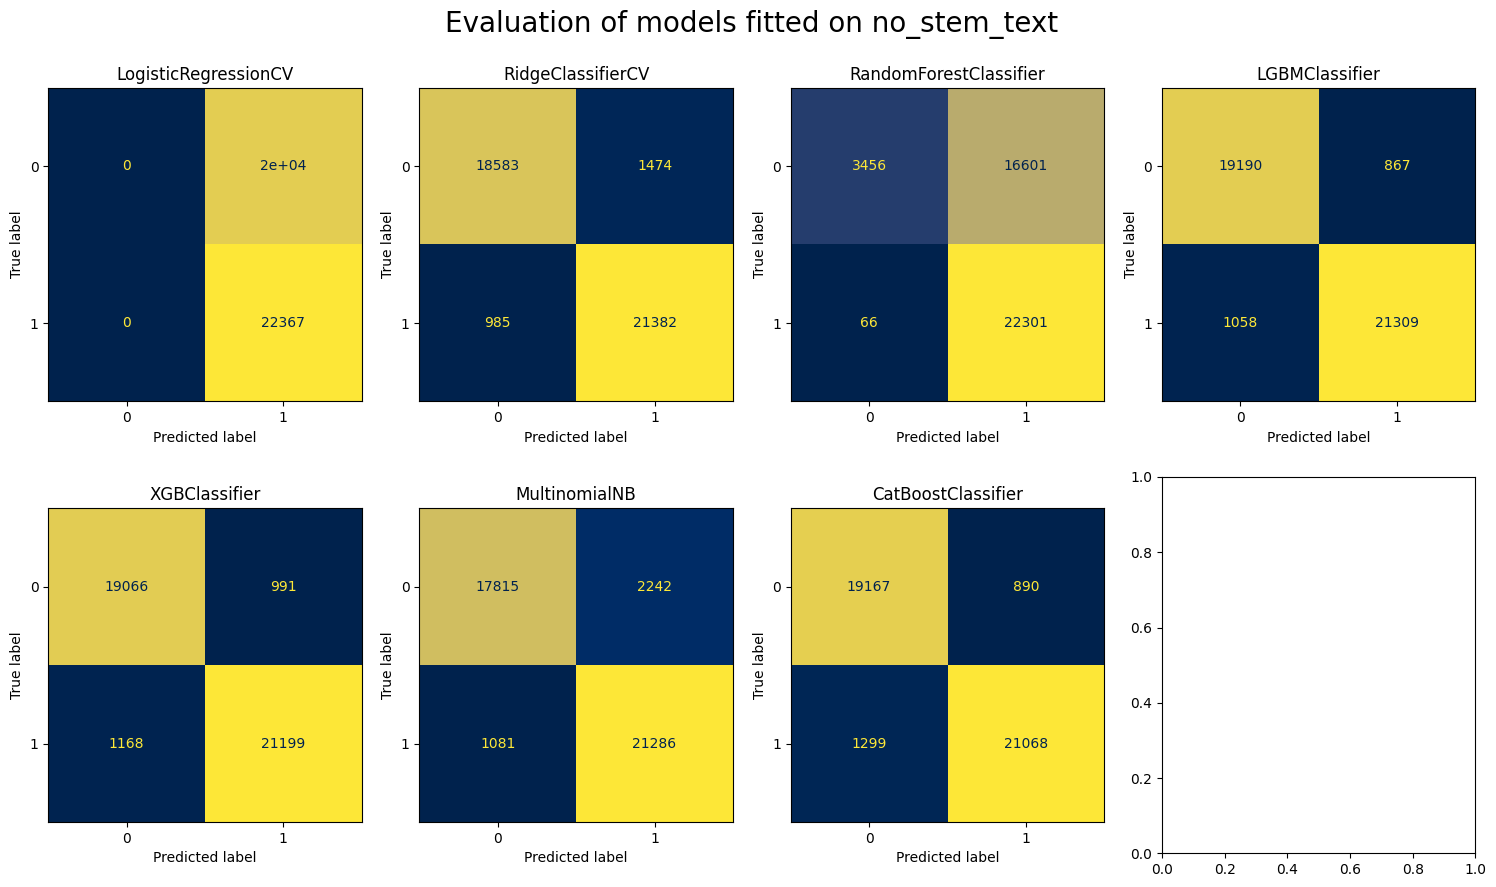

In [35]:
show_confusion_matrix(fitted_models, x_test, y_test)

In [36]:
from sklearn.metrics import RocCurveDisplay
def show_roc_auc(models, x_test, y_test, x_size=2, y_size=4, figwidth=15, figheight=9, fontsize=20):
    f, axes = plt.subplots(x_size, y_size)
    f.set_figwidth(figwidth)
    f.set_figheight(figheight)
    f.suptitle(f"Evaluation of models fitted on no_stem_text", fontsize=fontsize)
    f.tight_layout()
    for i, ax_row in enumerate(axes):
        for (model_name, model), ax in zip(list(models.items())[i*y_size:], ax_row):
            score = model.predict(x_test)
            RocCurveDisplay.from_predictions(y_test, score, color="darkorange", plot_chance_level=True, ax=ax)
            ax.set_title(model_name)

/Users/nikitadolgov/PycharmProjects/VVS/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/nikitadolgov/PycharmProjects/VVS/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/nikitadolgov/PycharmProjects/VVS/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/nikitadolgov/PycharmProjects/VVS/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature nam

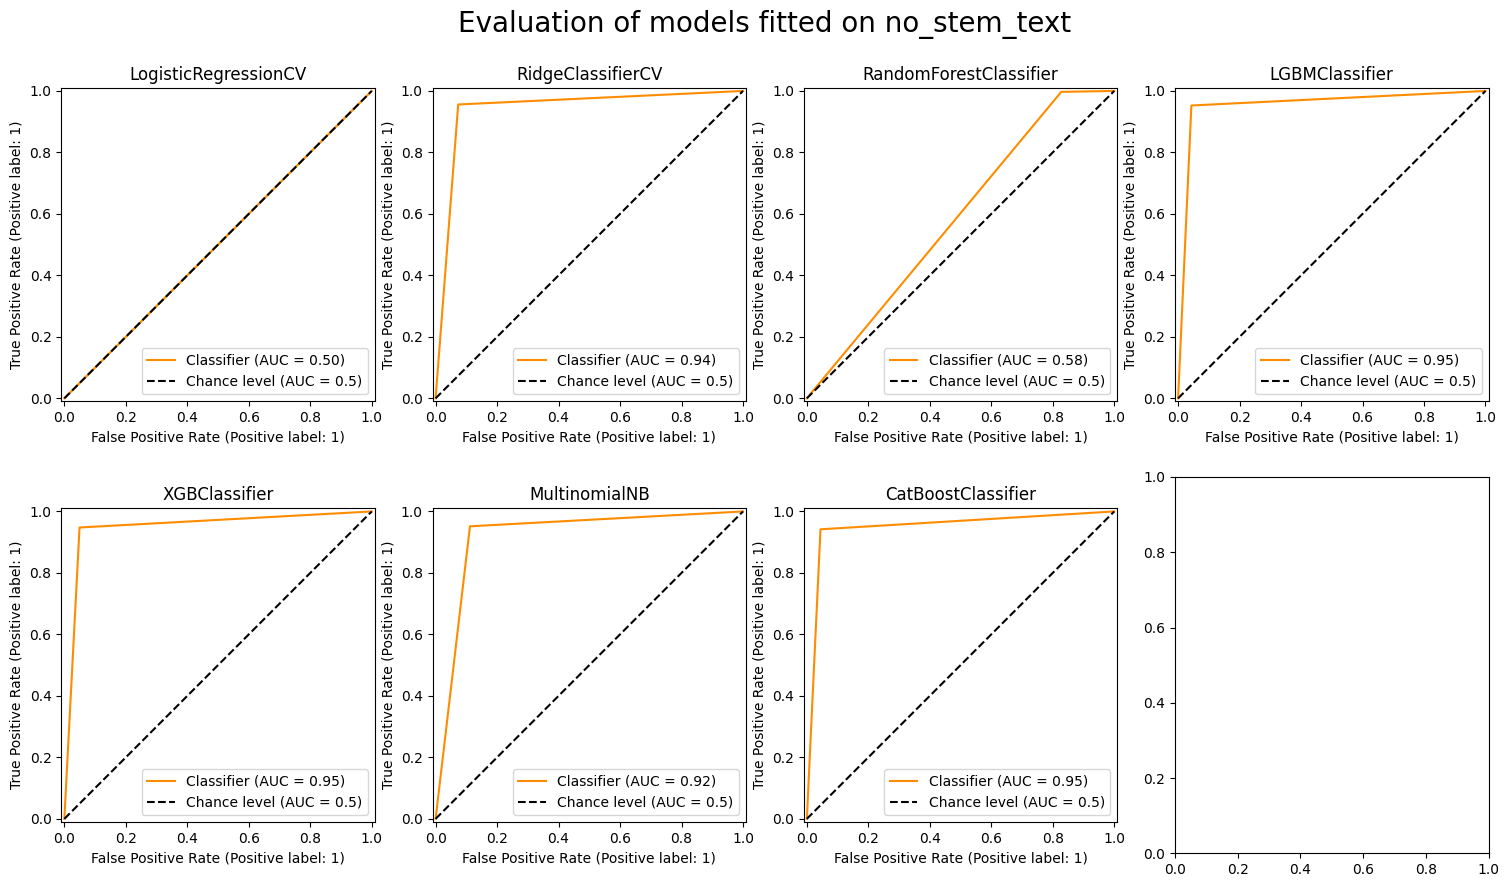

In [37]:
show_roc_auc(fitted_models, x_test, y_test)

In [5]:
import torch
from collections import Counter
import pandas as pd

# Загружаем твои данные (симуляция того, что у тебя в ноутбуке)
df = full_df
def build_vocab(texts, min_freq=2):
    # Счетчик всех слов
    counter = Counter()
    for text in texts:
        # Т.к. текст уже почищен, просто делим по пробелам
        if isinstance(text, str):
            counter.update(text.split())

    # Спецтокены: 0 - паддинг (пустышка), 1 - неизвестное слово (UNK)
    vocab = {"<PAD>": 0, "<UNK>": 1}
    idx = 2

    # Оставляем только слова, которые встречаются чаще min_freq
    for word, count in counter.items():
        if count >= min_freq:
            vocab[word] = idx
            idx += 1

    return vocab

# Строим словарь на основе TRAIN части (чтобы не подглядывать в тест)
# Важно: используем x_train из твоего ноутбука
vocab = build_vocab(x_train)

print(f"Размер словаря: {len(vocab)}")
# Можно глянуть, какой индекс у слова 'feel' (оно частое в твоем датасете)
print(f"Индекс слова 'feel': {vocab.get('feel', 'Нет в словаре')}")

Размер словаря: 21939
Индекс слова 'feel': 2


In [6]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

class EmotionDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        # Сбрасываем индексы, чтобы обращаться по [0], [1]...
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.vocab = vocab

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text_str = self.texts[idx]
        label = self.labels[idx]

        # 1. Разбиваем строку на слова
        if not isinstance(text_str, str): # Защита от NaN или мусора
            words = []
        else:
            words = text_str.split()

        # 2. Превращаем слова в цифры, используя наш словарь
        # vocab.get(w, 1) -> возвращает 1 (<UNK>), если слова нет в словаре
        indices = [self.vocab.get(w, 1) for w in words]

        # Если вдруг текст пустой, добавляем хотя бы один UNK или PAD, чтобы не упало
        if len(indices) == 0:
            indices = [0]

        return torch.tensor(indices, dtype=torch.long), torch.tensor(label, dtype=torch.float)

# Функция, чтобы выравнивать длину текстов в батче (padding)
def collate_batch(batch):
    text_list, label_list = [], []
    for (_text_tensor, _label) in batch:
        text_list.append(_text_tensor)
        label_list.append(_label)

    # Делаем все тексты одной длины (дополняем нулями <PAD>)
    # batch_first=True делает размерность [Batch_Size, Max_Len]
    text_list = pad_sequence(text_list, batch_first=True, padding_value=0)

    # Лейблы собираем в кучу
    label_list = torch.stack(label_list)

    return text_list, label_list

In [7]:
# Создаем Dataset для трейна
train_ds = EmotionDataset(x_train, y_train, vocab)

# Создаем DataLoader (батарейка, которая подает патроны-батчи)
BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)

# Берем один батч на пробу
text_batch, label_batch = next(iter(train_loader))

print("Размер батча с текстом:", text_batch.shape)
# Ожидаем: [64, Длина_самого_длинного_текста_в_батче]
print("Пример первого текста в цифрах:", text_batch[0])
print("Размер батча с метками:", label_batch.shape)

Размер батча с текстом: torch.Size([64, 25])
Пример первого текста в цифрах: tensor([ 125,  461,    2, 1850,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0])
Размер батча с метками: torch.Size([64])


In [ ]:
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import fbeta_score
import numpy as np
import time

# 1. Определяем архитектуру (Класс Модели)
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, n_layers, dropout):
        super().__init__()
        
        # Слой эмбеддингов: превращает индексы [1, 54, 23] в вектора
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        # LSTM слой
        # bidirectional=True сделает сеть мощнее (читает слева-направо и справа-налево)
        self.lstm = nn.LSTM(embed_dim, 
                            hidden_dim, 
                            num_layers=n_layers, 
                            bidirectional=True, 
                            dropout=dropout, 
                            batch_first=True)
        
        # Полносвязный слой
        # hidden_dim * 2, так как LSTM двунаправленная (bidirectional)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        
        # Dropout для борьбы с переобучением
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, text):
        # text: [batch size, sent len]
        
        embedded = self.dropout(self.embedding(text))
        # embedded: [batch size, sent len, emb dim]
        
        # LSTM возвращает output (все шаги) и (hidden, cell) (состояния)
        output, (hidden, cell) = self.lstm(embedded)
        
        hidden_final = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim = 1)
        # hidden_final: [batch size, hid dim * 2]
            
        return self.fc(self.dropout(hidden_final))

# 2. Гиперпараметры
INPUT_DIM = len(vocab)
EMBED_DIM = 100      
HIDDEN_DIM = 256     
OUTPUT_DIM = 1       
N_LAYERS = 2          
DROPOUT = 0.5         
LEARNING_RATE = 1e-3  

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

model = RNNClassifier(INPUT_DIM, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT)
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCEWithLogitsLoss()
criterion = criterion.to(device)

# --- ФУНКЦИИ ОБУЧЕНИЯ И ВАЛИДАЦИИ ---

def binary_accuracy(preds, y):
    rounded_preds = torch.round(torch.sigmoid(preds))
    correct = (rounded_preds == y).float()
    acc = correct.sum() / len(correct)
    return acc

def train(model, iterator, optimizer, criterion):
    epoch_loss = 0
    epoch_acc = 0
    model.train()
    
    for text, label in iterator:
        text, label = text.to(device), label.to(device)
        
        optimizer.zero_grad()       
        predictions = model(text).squeeze(1) 
        loss = criterion(predictions, label) 
        acc = binary_accuracy(predictions, label)
        
        loss.backward()             
        optimizer.step()             
        
        epoch_loss += loss.item()
        epoch_acc += acc.item()
        
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

def evaluate(model, iterator, criterion):
    epoch_loss = 0
    epoch_acc = 0
    all_preds = []
    all_labels = []
    
    model.eval() 
    
    with torch.no_grad(): 
        for text, label in iterator:
            text, label = text.to(device), label.to(device)
            predictions = model(text).squeeze(1)
            loss = criterion(predictions, label)
            acc = binary_accuracy(predictions, label)

            epoch_loss += loss.item()
            epoch_acc += acc.item()
            
            # Собираем для F-beta score
            probs = torch.sigmoid(predictions).cpu().numpy()
            preds = (probs >= 0.5).astype(int)
            all_preds.extend(preds)
            all_labels.extend(label.cpu().numpy())
    
    fbeta = fbeta_score(all_labels, all_preds, beta=2, average='weighted', zero_division=0)
    
    return epoch_loss / len(iterator), epoch_acc / len(iterator), fbeta

# --- ЗАПУСК ОБУЧЕНИЯ ---

N_EPOCHS = 5 

for epoch in range(N_EPOCHS):
    start_time = time.time()
    
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    end_time = time.time()
    
    print(f'Epoch: {epoch+1:02} | Time: {end_time - start_time:.0f}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')

Using device: mps
Epoch: 01 | Time: 84s
	Train Loss: 0.226 | Train Acc: 89.51%
Epoch: 02 | Time: 82s
	Train Loss: 0.108 | Train Acc: 95.34%
Epoch: 03 | Time: 105s
	Train Loss: 0.090 | Train Acc: 96.09%
Epoch: 04 | Time: 82s
	Train Loss: 0.081 | Train Acc: 96.52%
Epoch: 05 | Time: 91s
	Train Loss: 0.076 | Train Acc: 96.69%


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score, roc_auc_score, classification_report
from torch.utils.data import DataLoader

# 1. Создаем Test Loader
test_dataset = EmotionDataset(x_test, y_test, vocab) 
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, collate_fn=collate_batch, num_workers=0)

# 2. Функция для сбора всех предсказаний
def get_predictions(model, iterator, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for text, label in iterator:
            text = text.to(device)
            
            # Получаем логиты
            predictions = model(text).squeeze(1)
            # Превращаем в вероятности (0..1)
            probs = torch.sigmoid(predictions)
            
            # Собираем данные
            all_probs.extend(probs.cpu().numpy())
            # Порог 0.5 для класса 1
            all_preds.extend((probs >= 0.5).int().cpu().numpy())
            all_labels.extend(label.numpy())
            
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

# 3. Получаем предсказания
y_pred, y_true, y_prob = get_predictions(model, test_loader, device)

# 4. Считаем метрики (как в sklearn)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
fbeta = fbeta_score(y_true, y_pred, beta=2, average='weighted', zero_division=0)
roc_auc = roc_auc_score(y_true, y_prob)

# 5. Выводим отчет
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1 Score:    {f1:.4f}")
print(f"F-beta (2):  {fbeta:.4f}")
print(f"ROC AUC:     {roc_auc:.4f}")
print("-" * 30)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, zero_division=0))

--- Результаты на Test Set (42424 примеров) ---
Precision:   0.9696
Recall:      0.9696
F1 Score:    0.9696
F-beta (2):  0.9696  <-- Твоя целевая метрика
ROC AUC:     0.9968
------------------------------

Classification Report:

              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97     20057
         1.0       0.97      0.97      0.97     22367

    accuracy                           0.97     42424
   macro avg       0.97      0.97      0.97     42424
weighted avg       0.97      0.97      0.97     42424



In [10]:
import re

def predict_sentiment(text, model, vocab, device):
    model.eval()
    
    # 1. Минимальный препроцессинг (как у тебя в датасете примерно)
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text) # Убираем пунктуацию
    
    # 2. Токенизация (разбиваем на слова)
    tokens = text.split()
    
    # 3. Переводим в индексы
    # Если слова нет в словаре, ставим 1 (<UNK>)
    indices = [vocab.get(t, 1) for t in tokens]
    
    # 4. Превращаем в тензор и добавляем размерность батча [1, seq_len]
    tensor = torch.LongTensor(indices).unsqueeze(0).to(device)
    
    # 5. Предсказываем
    with torch.no_grad():
        prediction = model(tensor).squeeze(1)
        probability = torch.sigmoid(prediction).item()
        
    return probability

# --- ТЕСТИРУЕМ ---
my_device = device # Используем тот же device (mps или cpu)

# Примеры (на английском, т.к. датасет английский)
test_sentences = [
    "I really love this day, it is amazing!",
    "I feel so sad and lonely today.",
    "This is absolutely terrible, I hate it.",
    "I am not sure how I feel about this."
]

print("--- Живой тест ---")
for sent in test_sentences:
    prob = predict_sentiment(sent, model, vocab, my_device)
    label = "Positive 🙂" if prob >= 0.5 else "Negative ☹️"
    print(f"Текст: {sent}")
    print(f"Вероятность (Pos): {prob:.4f} | Вердикт: {label}\n")

--- Живой тест ---
Текст: I really love this day, it is amazing!
Вероятность (Pos): 0.7044 | Вердикт: Positive 🙂

Текст: I feel so sad and lonely today.
Вероятность (Pos): 0.0246 | Вердикт: Negative ☹️

Текст: This is absolutely terrible, I hate it.
Вероятность (Pos): 0.1144 | Вердикт: Negative ☹️

Текст: I am not sure how I feel about this.
Вероятность (Pos): 0.6260 | Вердикт: Positive 🙂



In [11]:
import os

# Создаем папку, если нет
os.makedirs("models_torch", exist_ok=True)

# 1. СОХРАНЕНИЕ
# Сохраняем не только веса, но и словарь (vocab), и параметры архитектуры!
# Без словаря новая модель не поймет, что слово "happy" это индекс 542.
torch.save({
    'model_state_dict': model.state_dict(),
    'vocab': vocab,  # Наш словарь
    'hyperparams': { # Параметры, чтобы потом инициализировать класс так же
        'embed_dim': EMBED_DIM,
        'hidden_dim': HIDDEN_DIM,
        'output_dim': OUTPUT_DIM,
        'n_layers': N_LAYERS,
        'dropout': DROPOUT
    }
}, 'models_torch/lstm_model_097.pth')

print("Модель успешно сохранена!")

Модель успешно сохранена!
